In [5]:
from tools import load
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib.lines import Line2D
from math import comb

In [6]:
def backward_diff_array(y, h, n):
    coeffs = np.array([(-1)**k * comb(n, k) for k in range(n + 1)])
    raw = np.convolve(y, coeffs, mode='valid') / h**n
    return np.concatenate([np.zeros(n), raw])


def expand_with_derivatives(data, h, max_order):
    if max_order == 0:
        return data.copy()
    derivs = [np.apply_along_axis(lambda c: backward_diff_array(c, h, o),
                                  axis=0, arr=data)
              for o in range(1, max_order + 1)]
    return np.hstack([data] + derivs)


n_sensors = 8
all_ordered_pairs = [(i, j) for i in range(n_sensors)
                     for j in range(n_sensors) if i != j]  # 56 pairs

def make_ratios(data, pairs, n):
    return np.column_stack([data[:, i] / (data[:, j] + 1e-8) for i, j in pairs[:n]])

def make_diffs(data, pairs, n):
    return np.column_stack([data[:, i] - data[:, j] for i, j in pairs[:n]])

def build_136(sensor_data, h):
    x_d12 = expand_with_derivatives(sensor_data, h, 2)
    r56 = make_ratios(sensor_data, all_ordered_pairs, 56)
    d56 = make_diffs(sensor_data, all_ordered_pairs, 56)
    return np.hstack([x_d12, r56, d56])

In [7]:
file = '1_600_20'
i0, i1 = 290, 500

sensor_data, sequence, times_sec, sequence_sec = load(file, reduced=True)
h = np.median(np.diff(times_sec))
x_dense = build_136(sensor_data, h)
n_dense = x_dense.shape[1]
print(f"Expanded features: {n_dense}")

Expanded features: 136


In [26]:
n_out = 1
n_hd = 10000
k = 5000
c1 = 'white'
p_list = [1./1000, 1./5000, 1./25000]

rng = np.random.default_rng(42)

colour = np.zeros_like(times_sec, dtype=int)
runs = []
for j in range(len(sequence_sec)):
    t0 = sequence_sec[j]
    t1 = sequence_sec[j+1] if j+1 < len(sequence_sec) else np.inf
    mask = (times_sec >= t0) & (times_sec < t1)
    colour[mask] = int(sequence[j][1])
    idx_start = np.where((times_sec >= t0) & (np.roll(times_sec, 1) <= t0) == True)[0]
    idx_end = np.where((np.roll(times_sec, -1) > t1) & (times_sec <= t1) == True)[0]
    if idx_end.size == 0:
        idx_end = len(times_sec)
    runs.append((int(idx_start), int(idx_end), int(sequence[j][1])))

results = []  # list of (gid, tc, mean_os) per p

for idx_p, p in enumerate(p_list):
    W_hd = np.random.binomial(n=1, p=0.025, size=(n_hd, n_dense))
    x_hd = x_dense @ W_hd.T
    ranks = np.argsort(np.argsort(-x_hd, axis=1), axis=1)
    z_hd = np.where(ranks < k, 1., 0.)
    W_out = np.zeros((n_out, n_hd))
    output = np.zeros((x_dense.shape[0]))

    for i, row in enumerate(z_hd):
        active_idx = np.flatnonzero(row)
        to_flip = active_idx[rng.random(active_idx.size) < p]
        W_out[0, to_flip] = 1.0
        output[i] = row @ W_out.T

    gas_presentations = {}
    gas_id_list, true_count_list, length_list, output_sum_list = [], [], [], []

    for s, e, gas_id in runs:
        if gas_id == 0:
            continue
        gas_presentations[gas_id] = gas_presentations.get(gas_id, 0) + 1
        gas_id_list.append(gas_id)
        true_count_list.append(gas_presentations[gas_id])
        length_list.append(e - s)
        output_sum_list.append(float(output[s:e].sum()))

    gid = np.asarray(gas_id_list)
    tc  = np.asarray(true_count_list)
    L   = np.asarray(length_list, dtype=float)
    os_ = np.asarray(output_sum_list, dtype=float)
    mean_os = os_ / np.maximum(L, 1.0)

    results.append((gid, tc, mean_os))

/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_40979/2288634480.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  runs.append((int(idx_start), int(idx_end), int(sequence[j][1])))
/var/folders/w2/znr__42x45s1rjb1hj583bbr0000gn/T/ipykernel_40979/2288634480.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output[i] = row @ W_out.T


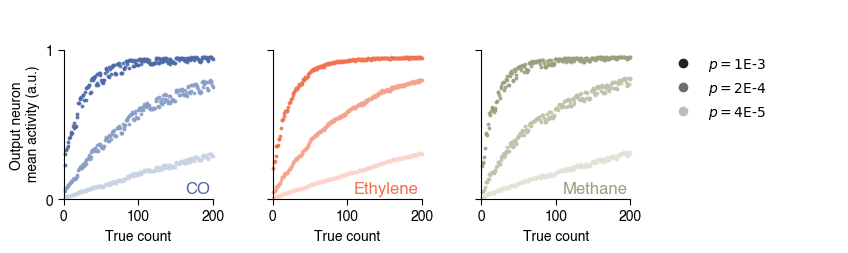

In [28]:
cm = ListedColormap(plt.rcParams['axes.prop_cycle'].by_key()['color'])
fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharex=True, sharey=True, gridspec_kw={"wspace": 0.4})
axes = axes.flatten()

labels = {1: 'CO', 2: 'Ethylene', 3: 'Methane'}

for idx_p, (gid, tc, mean_os) in enumerate(results):
    for ax, gas in zip(axes[:3], [1, 2, 3]):
        graded_cm = LinearSegmentedColormap.from_list("to_light", [cm((gas - 1)), c1])
        colors = [graded_cm(t) for t in np.linspace(0., 0.7, len(p_list))]
        m = (gid == gas)
        ax.scatter(
            tc[m], mean_os[m],
            marker='.', s=30, lw=0.,
            color=colors[idx_p], alpha=0.9, clip_on=False,
        )

for ax, gas in zip(axes, [1, 2, 3]):
    ax.text(
        0.98, 0.02, labels.get(gas, f'Gas {gas}'),
        transform=ax.transAxes, ha='right', va='bottom',
        color=cm(gas-1), fontsize=12,
    )

    ax.set_xlim(0, 200)
    ax.set_ylim(0, ax.get_ylim()[1])
    ax.spines['left'].set_position(('data', 0))
    ax.spines['bottom'].set_position(('data', 0))
    ax.set_xticks([0, 100, 200])
    ax.set_yticks(ax.get_ylim(), [0, 1])
    ax.set_box_aspect(1)

axes[0].set_ylabel('Output neuron\n mean activity (a.u.)')
for ax in axes:
    ax.set_xlabel("True count")

graded_cm = LinearSegmentedColormap.from_list("to_light", [cm(4), c1])
legend_colors = [graded_cm(t) for t in np.linspace(0., 0.7, len(p_list))]

handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=legend_colors[i], markeredgecolor='none', markersize=7)
    for i in range(len(p_list))
]

def sci_label(v):
    exp = int(np.floor(np.log10(v)))
    coeff = v / 10**exp
    if coeff == int(coeff):
        coeff = int(coeff)
    return fr"$p={coeff}\text{{E-}}{-exp}$"

labels_leg = [sci_label(p) for p in p_list]
axes[3].set_axis_off()
axes[3].legend(
    handles, labels_leg,
    bbox_to_anchor=(0.6, 0.85),
    frameon=False,
    ncol=1,
)

plt.savefig("figs/count_sketch.pdf", bbox_inches="tight")
plt.show()